# Jets with FastJet: spectrum, fragmentation function, jet area and $\rho$ subtraction

A test of jet finding on the hadron files of a campaign with the FastJet Python bindings
(`pip install fastjet`, scikit-hep, which wraps the C++ classes): anti-$k_T$, $R = 0.4$.

| section | events | what |
|---|---|---|
| 2 | **jet** = `jet_frag` samples alone | jet spectrum and fragmentation function of the jet hadrons, no background |
| 3 | AuAu | is the jet area right? (total area, $\pi R^2$ for hard jets, ghost-size scan) |
| 4 | AuAu | $\rho$ from $k_T$ jets without the two leading ones, per event; random cones |
| 5 | AuAu | jet spectrum with and without $\rho A$ subtraction; embedding $\delta p_T$ |

**The AuAu events.** For event $e$ and oversample $k$, three events are built from the hadron files
(`HadronFileReader`):

| label | hadrons | what it tests |
|---|---|---|
| **bkg** | `bulk_bg` sample $k$ | pure background: $\rho$, random cones, combinatorial jets |
| **bkg + jet** | `bulk_bg` sample $k$ + `jet_frag` sample $k \bmod n_\mathrm{frag}$ | embedding: the jet on a background it did not touch, so $\langle\delta p_T\rangle = 0$ if the subtraction is right |
| **bkg + wake + jet** | `bulk_jet` sample $k$ + the same `jet_frag` sample | the full event (`reader.jet_event`): the medium response is in the bulk |

**Choices** (first code cell): hadrons with $|\eta| < 1.5$ and $p_T > 0.15$ GeV, charged ones by default
(`PARTICLES=full` for all); they are clustered as massless ($E = |\vec p|$), so rapidity $=$ pseudorapidity
and the ghosts cover exactly the particle acceptance. Signal jets have $|\eta| < 1.5 - R$. Areas are active
areas with explicit ghosts (ghost area 0.005). $\rho$ is the median of $p_{T}/A$ of the $k_T$ ($R = 0.4$)
jets with $|\eta| < 1.5 - R$ after removing the two hardest of them
(`JetMedianBackgroundEstimator` with `set_use_area_4vector(False)`: FastJet 3 divides by the transverse
part of the 4-vector area by default, about 2% smaller than $A$ for $R = 0.4$, which gives a $\approx 1$ GeV
larger $\rho$), and a jet's subtracted momentum is $p_{T} - \rho A$ with the same scalar area.

**Statistics.** Oversamples of one event share one fluid, and the fragmentations of one event share
its partons: the samples are not independent collisions. The error bars are the sampling noise
of the samples at hand; with a few events the spectra show those few dijets, not a jet population.

    HADRON_DIR=/path/to/out MAX_EVENTS=200 MAX_OVERSAMPLES=100 jupyter nbconvert --to notebook --execute jet_fastjet.ipynb

In [1]:
%matplotlib inline
import os
import sys
import time
try:  # registers Blosc, the default compression of the hadron files
    import hdf5plugin  # noqa: F401
except ImportError:
    print("note: pip install hdf5plugin -- needed for Blosc-compressed files (lzf files read without it)")
import numpy as np
import matplotlib.pyplot as plt
import fastjet as fj

sys.path.insert(0, os.path.join("..", "..", "python"))
from jetscape.hadrons_h5 import CHARGED, HadronFile, HadronFileReader

# --- inputs ---------------------------------------------------------------------------------
HADRON_DIR = os.environ.get("HADRON_DIR", os.path.join("..", "prod_AuAu_0_10_jet", "out"))
MAX_EVENTS = int(os.environ.get("MAX_EVENTS", "0")) or None            # None: every event
MAX_OVERSAMPLES = int(os.environ.get("MAX_OVERSAMPLES", "0")) or None  # per event; None: all
PARTICLES = os.environ.get("PARTICLES", "charged")   # 'charged' or 'full'

# --- jet finding ----------------------------------------------------------------------------
R = 0.4                 # anti-kT signal jets
R_BKG = 0.4             # kT jets for rho
ETA_MAX = 1.5           # particle acceptance |eta| (= |y|: the particles are made massless)
PT_MIN_PART = 0.15      # GeV
JET_ETA = ETA_MAX - R   # signal jets fully inside the acceptance
BKG_ETA = ETA_MAX - R_BKG
N_EXCL = 2              # hardest kT jets left out of rho
GHOST_AREA = 0.005
JET_PT_MIN_FRAG = 10.0  # GeV, jets of section 2 and the embedding reference
FF_PT_BINS = [(10, 20), (20, 30), (30, 60)]   # GeV, fragmentation function jet-pT bins
RNG = np.random.default_rng(2026)             # random cones

# --- colors: one per event type, fixed (categorical slots 1-4) ------------------------------
COL = {"jet": "#2a78d6", "bkg": "#eb6834", "bkg+wake+jet": "#1baf7a", "bkg+jet": "#4a3aa7"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "lines.linewidth": 2, "figure.dpi": 110,
                     "legend.frameon": False})
print(fj.fastjet_version_string() if hasattr(fj, "fastjet_version_string") else "", "| fastjet", fj.__version__)

FastJet version 3.5.1 | fastjet 3.5.1.5


## 1. The data set

In [2]:
reader = HadronFileReader(HADRON_DIR)
missing = [t for t in ("bulk_jet", "bulk_bg", "jet_frag") if t not in reader.tags()]
if missing:
    raise SystemExit(f"not every production file in {HADRON_DIR} has {missing}")
events = reader.events(slice(0, MAX_EVENTS))
EVENTS = np.array([e for e in events if reader.n_frag(e) > 0 and reader.n_oversamples(e) > 0
                   and reader.n_samples("bulk_bg", e) > 0], dtype=int)
N_EV = len(EVENTS)
N_FRAG = {int(e): reader.n_frag(e) for e in EVENTS}
N_OVER = {int(e): min(reader.n_oversamples(e), reader.n_samples("bulk_bg", e), MAX_OVERSAMPLES or 10**9)
          for e in EVENTS}
print(f"{HADRON_DIR}: {reader.n_files} production file(s), {reader.n_events} event(s); using {N_EV}")
print(f"  jet_frag samples/event {sorted(set(N_FRAG.values()))}, AuAu oversamples/event used "
      f"{sorted(set(N_OVER.values()))}  ->  {sum(N_FRAG.values())} jet events, "
      f"{sum(N_OVER.values())} AuAu events per event type")
print(f"  particles: {PARTICLES}, |eta| < {ETA_MAX}, pT > {PT_MIN_PART} GeV; anti-kT R = {R}, "
      f"jets |eta| < {JET_ETA:.1f}; rho: kT R = {R_BKG}, |eta| < {BKG_ETA:.1f}, {N_EXCL} hardest out")

# jet_frag files, opened once for single fragmentation samples
_frag_files = {}


def frag_sample(e, j):
    i, local = reader.locate(e)
    if i not in _frag_files:
        _frag_files[i] = HadronFile(f"{reader.stems[i]}_hadrons_jet_frag.h5")
    return _frag_files[i].sample_event(local, j)

../prod_AuAu_0_10_jet/out: 2 production file(s), 2 event(s); using 2
  jet_frag samples/event [50], AuAu oversamples/event used [500]  ->  100 jet events, 1000 AuAu events per event type
  particles: charged, |eta| < 1.5, pT > 0.15 GeV; anti-kT R = 0.4, jets |eta| < 1.1; rho: kT R = 0.4, |eta| < 1.1, 2 hardest out


### FastJet set-up

`to_pseudojets` applies the particle cuts and gives every particle `user_index` = its row in the
event; for combined events the jet hadrons get `FRAG_OFFSET` + their row in the `jet_frag`
sample, so a jet's momentum from jet hadrons is known exactly (section 5). The ghosts are placed
with random jitter at every clustering (the Python bindings cannot set FastJet's ghost seed), so
areas and $\rho$ change slightly from run to run; section 4 measures how much.

In [3]:
CHARGED_PID = np.array(CHARGED)
FRAG_OFFSET = 10_000_000


def kinematics(p):
    p = np.asarray(p, dtype=np.float64)
    px, py, pz = p[:, 1], p[:, 2], p[:, 3]
    pt = np.hypot(px, py)
    pabs = np.sqrt(pt ** 2 + pz ** 2)
    eta = np.arcsinh(pz / np.maximum(pt, 1e-12))
    return px, py, pz, pt, pabs, eta


def to_pseudojets(ev, index_offset=0):
    # massless PseudoJets of the accepted hadrons of one sample (dict of pid, p, ...)
    px, py, pz, pt, pabs, eta = kinematics(ev["p"])
    keep = (np.abs(eta) < ETA_MAX) & (pt > PT_MIN_PART)
    if PARTICLES == "charged":
        keep &= np.isin(np.abs(ev["pid"]), CHARGED_PID)
    out = []
    for i in np.flatnonzero(keep):
        pj = fj.PseudoJet(px[i], py[i], pz[i], pabs[i])
        pj.set_user_index(int(i) + index_offset)
        out.append(pj)
    return out


JET_DEF = fj.JetDefinition(fj.antikt_algorithm, R)
BKG_DEF = fj.JetDefinition(fj.kt_algorithm, R_BKG)


def area_def(ghost_area=GHOST_AREA):
    return fj.AreaDefinition(fj.active_area_explicit_ghosts, fj.GhostedAreaSpec(ETA_MAX, 1, ghost_area))


AREA_DEF = area_def()

# rho: the two hardest kT jets inside |eta| < BKG_ETA left out.  s1 * s2 applies s2 first.
SEL_RHO = (~fj.SelectorNHardest(N_EXCL)) * fj.SelectorAbsRapMax(BKG_ETA)
SEL_RHO0 = fj.SelectorAbsRapMax(BKG_ETA)          # no exclusion, for comparison
SEL_JET = fj.SelectorAbsRapMax(JET_ETA)


def real(jet):
    # the non-ghost constituents
    return [c for c in jet.constituents() if not c.is_pure_ghost()]


def rho_sigma(kt_jets, selector):
    est = fj.JetMedianBackgroundEstimator(selector, BKG_DEF, AREA_DEF)
    est.set_use_area_4vector(False)   # median of pT / A, the A of pT - rho A (FastJet 3 default: |A_4vec|)
    est.set_jets(kt_jets)      # the jets we clustered: no second clustering with other ghosts
    return est.rho(), est.sigma()


print(JET_DEF.description())
print(AREA_DEF.description())
print("rho selector:", SEL_RHO.description())

Longitudinally invariant anti-kt algorithm with R = 0.4 and E scheme recombination
Active area (explicit ghosts) with ghosts of area 0.00504268 (had requested 0.005), placed up to y = 1.5, scattered wrt to perfect grid by (rel) 1, mean_ghost_pt = 1e-100, rel pt_scatter =  0.1, n repetitions of ghost distributions =  1
rho selector: (!(2 hardest) * |rap| <= 1.1)


## 2. Jets of the jet hadrons alone: spectrum and fragmentation function

Every `jet_frag` sample (a ColorlessHadronization of the event's final partons) is one event
here, with no background. The fragmentation function uses the longitudinal momentum fraction
$z = \vec p_h\cdot\vec p_\mathrm{jet}/|\vec p_\mathrm{jet}|^2$ of the jet's constituents and
$\xi = \ln(1/z)$, per jet: $D(z) = \frac{1}{N_\mathrm{jet}}\frac{dN_h}{dz}$.

In [4]:
t0 = time.time()
FRAG_JETS = {}          # (event, sample) -> list of jet records, for the embedding in section 5
cols = {k: [] for k in ("event", "sample", "pt", "eta", "phi", "area", "n", "ptlead")}
ff_z, ff_jpt = [], []
total_area_frag = []
for e in EVENTS:
    for j in range(N_FRAG[int(e)]):
        parts = to_pseudojets(frag_sample(e, j))
        cs = fj.ClusterSequenceArea(parts, JET_DEF, AREA_DEF)
        all_jets = cs.inclusive_jets()                       # ghost-only jets too: they tile the area
        total_area_frag.append(sum(jt.area() for jt in all_jets))
        recs = []
        for jet in fj.sorted_by_pt(SEL_JET(cs.inclusive_jets(JET_PT_MIN_FRAG))):
            con = real(jet)
            pj = np.array([jet.px(), jet.py(), jet.pz()])
            ph = np.array([[c.px(), c.py(), c.pz()] for c in con])
            z = ph @ pj / (pj @ pj)
            ff_z.append(z); ff_jpt.append(np.full(len(z), jet.pt()))
            for k, v in zip(cols, (e, j, jet.pt(), jet.eta(), jet.phi_std(), jet.area(), len(con),
                                   np.hypot(ph[:, 0], ph[:, 1]).max())):
                cols[k].append(v)
            recs.append({"pt": jet.pt(), "eta": jet.eta(), "phi": jet.phi_std(), "area": jet.area(),
                         "idx": {c.user_index() for c in con}})
        FRAG_JETS[(int(e), j)] = recs
FJ = {k: np.array(v) for k, v in cols.items()}
ff_z, ff_jpt = np.concatenate(ff_z), np.concatenate(ff_jpt)
N_FRAG_SAMPLES = sum(N_FRAG.values())
print(f"{N_FRAG_SAMPLES} jet samples in {time.time() - t0:.1f} s: {len(FJ['pt'])} jets with pT > "
      f"{JET_PT_MIN_FRAG} GeV, |eta| < {JET_ETA:.1f} ({len(FJ['pt']) / N_FRAG_SAMPLES:.2f} per sample)")
for e in EVENTS:
    m = FJ["event"] == e
    ini = reader.event_info(e).initiators()
    pt_i = np.hypot(ini[:, 3], ini[:, 4])
    eta_i = np.arcsinh(ini[:, 5] / pt_i)
    print(f"  event {e}: initiators pT {np.round(pt_i, 1)} GeV at eta {np.round(eta_i, 2)}, "
          f"phi {np.round(np.arctan2(ini[:, 4], ini[:, 3]), 2)};  jets: <pT> {FJ['pt'][m].mean():.1f} GeV, "
          f"eta/phi of the leading one per sample: "
          + ", ".join(sorted({f"({a:.1f}, {b:.1f})" for a, b in zip(FJ['eta'][m], FJ['phi'][m])})[:4]))

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


100 jet samples in 0.7 s: 173 jets with pT > 10.0 GeV, |eta| < 1.1 (1.73 per sample)
  event 0: initiators pT [52.7 49.9] GeV at eta [ 0.44 -0.86], phi [-2.56  0.55];  jets: <pT> 26.6 GeV, eta/phi of the leading one per sample: (-0.8, 0.5), (-0.8, 0.6), (-0.9, 0.5), (-0.9, 0.6)
  event 1: initiators pT [63.9 63.6  8.8  2.6] GeV at eta [ 0.34 -0.06  0.15  0.16], phi [ 0.53 -2.58 -2.86  0.51];  jets: <pT> 35.8 GeV, eta/phi of the leading one per sample: (-0.0, -2.5), (-0.0, -2.6), (-0.0, -2.7), (-0.1, -2.5)


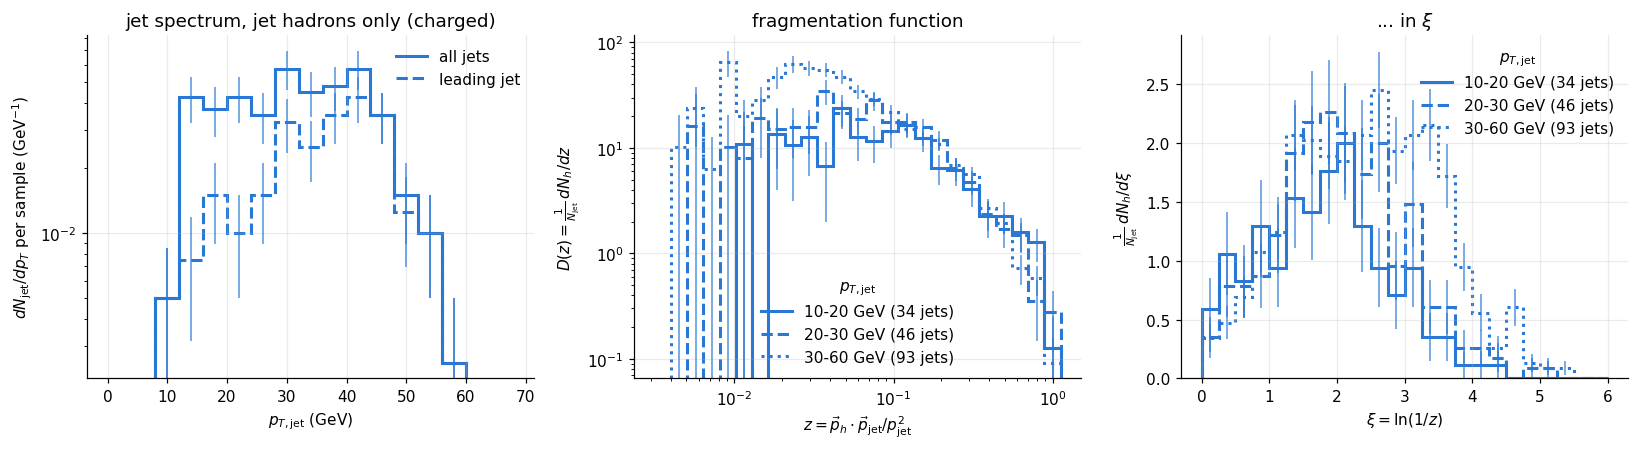

integral of D(z) = constituents per jet: 5.8 (mean n = 5.8); 2 single-hadron jets (z = 1)


In [5]:
def per_sample_hist(values, event_of, bins, n_samples):
    # event average of per-sample-mean histograms, and the sampling error
    h, v = np.zeros(len(bins) - 1), np.zeros(len(bins) - 1)
    evs = list(n_samples)
    for e in evs:
        c = np.histogram(values[event_of == e], bins)[0]
        h += c / n_samples[e]
        v += c / n_samples[e] ** 2
    return h / len(evs), np.sqrt(v) / len(evs)


def step(ax, bins, h, err, label, color, ls="-", width=None):
    c = 0.5 * (bins[1:] + bins[:-1])
    d = np.diff(bins) if width is None else width
    ax.stairs(h / d, bins, color=color, ls=ls, lw=2, label=label)
    ax.errorbar(c, h / d, err / d, fmt="none", ecolor=color, elinewidth=1, alpha=0.8)


PT_BINS = np.arange(0, 72, 4.0)
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
h, err = per_sample_hist(FJ["pt"], FJ["event"], PT_BINS, N_FRAG)
step(axs[0], PT_BINS, h, err, "all jets", COL["jet"])
first = np.r_[True, (np.diff(FJ["event"]) != 0) | (np.diff(FJ["sample"]) != 0)]   # sorted by pT
h, err = per_sample_hist(FJ["pt"][first], FJ["event"][first], PT_BINS, N_FRAG)
step(axs[0], PT_BINS, h, err, "leading jet", COL["jet"], ls="--")
axs[0].set(xlabel=r"$p_{T,\mathrm{jet}}$ (GeV)", ylabel=r"$dN_\mathrm{jet}/dp_T$ per sample (GeV$^{-1}$)",
           yscale="log", title=f"jet spectrum, jet hadrons only ({PARTICLES})")
axs[0].legend()

Z_BINS = np.logspace(-2.5, 0.05, 26)
XI_BINS = np.linspace(0, 6, 25)
ls = ["-", "--", ":"]
for (lo, hi), s in zip(FF_PT_BINS, ls):
    nj = ((FJ["pt"] >= lo) & (FJ["pt"] < hi)).sum()
    if nj == 0:
        continue
    m = (ff_jpt >= lo) & (ff_jpt < hi)
    for ax, x, b in ((axs[1], ff_z[m], Z_BINS), (axs[2], np.log(1 / ff_z[m]), XI_BINS)):
        c = np.histogram(x, b)[0]
        step(ax, b, c / nj, np.sqrt(c) / nj, f"{lo}-{hi} GeV ({nj} jets)", COL["jet"], ls=s)
axs[1].set(xscale="log", yscale="log", xlabel=r"$z = \vec p_h\cdot\vec p_\mathrm{jet}/p_\mathrm{jet}^2$",
           ylabel=r"$D(z) = \frac{1}{N_\mathrm{jet}}\,dN_h/dz$", title="fragmentation function")
axs[2].set(xlabel=r"$\xi = \ln(1/z)$", ylabel=r"$\frac{1}{N_\mathrm{jet}}\,dN_h/d\xi$", title="... in $\\xi$")
axs[1].legend(title=r"$p_{T,\mathrm{jet}}$"); axs[2].legend(title=r"$p_{T,\mathrm{jet}}$")
plt.tight_layout(); plt.show()
print(f"integral of D(z) = constituents per jet: {len(ff_z) / len(FJ['pt']):.1f} (mean n = {FJ['n'].mean():.1f}); "
      f"{int((FJ['n'] == 1).sum())} single-hadron jets (z = 1)")

## 3. Is the jet area working?

Four checks, all from the explicit-ghost clustering:

1. **The areas tile the acceptance.** With explicit ghosts every ghost ends up in some jet (the
   ghost-only ones included), so the areas of all jets of an event add up to $2\,\eta_\mathrm{max}\cdot 2\pi$.
2. **Hard jets have $A \approx \pi R^2$.** Anti-$k_T$ jets grow as cones around hard cores: their area
   is $\pi R^2 = 0.503$ unless another hard jet is closer than $2R$. Soft jets in the background
   have a broader area distribution.
3. **The same jet, alone and in AuAu.** The jet hadrons' jet has the same area with and without
   the background around it (matched jets, section 5's matching).
4. **Ghost size.** $\langle A\rangle$ of hard jets and $\rho$ must not depend on the ghost area.

In [6]:
t0 = time.time()
LEGS = ("bkg", "bkg+jet", "bkg+wake+jet")
R_REC = {leg: {k: [] for k in ("event", "k", "rho", "sigma", "rho0", "rho_naive", "n_kt", "n_empty",
                                "total_area", "lead_kt")} for leg in LEGS}
RHO_REGHOST = []        # bkg clustered a second time (new ghosts): the ghosts' own noise on rho
J_REC = {leg: {k: [] for k in ("event", "k", "pt", "area", "eta", "phi", "rho")} for leg in LEGS}
M_REC = {leg: {k: [] for k in ("event", "k", "pt_frag", "area_frag", "pt", "area", "rho", "frag_share", "dR")}
         for leg in LEGS[1:]}
RC = {k: [] for k in ("event", "sum_pt", "rho")}
ACC_AREA = 2 * ETA_MAX * 2 * np.pi


def analyse(leg, e, k, parts, frag_j=None):
    cs = fj.ClusterSequenceArea(parts, JET_DEF, AREA_DEF)
    all_jets = cs.inclusive_jets()
    csk = fj.ClusterSequenceArea(parts, BKG_DEF, AREA_DEF)
    kt = fj.sorted_by_pt(csk.inclusive_jets())
    rho, sigma = rho_sigma(kt, SEL_RHO)
    rho0, _ = rho_sigma(kt, SEL_RHO0)
    sel_kt = SEL_RHO0(kt)
    r = R_REC[leg]
    for key, v in (("event", e), ("k", k), ("rho", rho), ("sigma", sigma), ("rho0", rho0),
                   ("rho_naive", sum(p.pt() for p in parts if abs(p.eta()) < BKG_ETA) / (2 * BKG_ETA * 2 * np.pi)),
                   ("n_kt", sum(1 for j in sel_kt if not j.is_pure_ghost())),
                   ("n_empty", sum(1 for j in sel_kt if j.is_pure_ghost())),
                   ("total_area", sum(j.area() for j in all_jets)),
                   ("lead_kt", [j.pt() for j in fj.sorted_by_pt(sel_kt)[:N_EXCL]])):
        r[key].append(v)
    jets = fj.sorted_by_pt(SEL_JET(cs.inclusive_jets(1.0)))
    jr = J_REC[leg]
    for jet in jets:
        for key, v in (("event", e), ("k", k), ("pt", jet.pt()), ("area", jet.area()), ("eta", jet.eta()),
                       ("phi", jet.phi_std()), ("rho", rho)):
            jr[key].append(v)
    if frag_j is not None:   # match each jet-hadron jet to the AuAu jet with most of its hadrons
        for fr in FRAG_JETS[(int(e), frag_j)]:
            best, share = None, 0.0
            for jet in jets:
                s = sum(c.pt() for c in real(jet) if c.user_index() - FRAG_OFFSET in fr["idx"])
                if s > share:
                    best, share = jet, s
            if best is None:
                continue
            m = M_REC[leg]
            dr = np.hypot(best.eta() - fr["eta"], (best.phi_std() - fr["phi"] + np.pi) % (2 * np.pi) - np.pi)
            for key, v in (("event", e), ("k", k), ("pt_frag", fr["pt"]), ("area_frag", fr["area"]),
                           ("pt", best.pt()), ("area", best.area()), ("rho", rho),
                           ("frag_share", share / fr["pt"]), ("dR", dr)):
                m[key].append(v)
    return rho


for e in EVENTS:
    for k in range(N_OVER[int(e)]):
        j = k % N_FRAG[int(e)]
        bkg = to_pseudojets(reader.background_event(e, k))
        frag = to_pseudojets(frag_sample(e, j), FRAG_OFFSET)
        full = reader.jet_event(e, k)                     # bulk_jet sample k + jet_frag sample k mod n
        assert int((full["origin"] == 1).sum()) == len(frag_sample(e, j)["pid"])
        bulk_jet = {key: full[key][full["origin"] == 0] for key in ("pid", "p")}
        rho_bkg = analyse("bkg", e, k, bkg)
        csk = fj.ClusterSequenceArea(bkg, BKG_DEF, AREA_DEF)
        RHO_REGHOST.append(rho_sigma(fj.sorted_by_pt(csk.inclusive_jets()), SEL_RHO)[0])
        analyse("bkg+jet", e, k, bkg + frag, frag_j=j)
        analyse("bkg+wake+jet", e, k, to_pseudojets(bulk_jet) + frag, frag_j=j)
        # one random cone per background sample
        eta_c, phi_c = RNG.uniform(-JET_ETA, JET_ETA), RNG.uniform(-np.pi, np.pi)
        RC["event"].append(e); RC["rho"].append(rho_bkg)
        RC["sum_pt"].append(sum(p.pt() for p in bkg
                                if np.hypot(p.eta() - eta_c, (p.phi_std() - phi_c + np.pi) % (2 * np.pi) - np.pi) < R))
R_REC = {leg: {k: (np.array(v) if k != "lead_kt" else v) for k, v in d.items()} for leg, d in R_REC.items()}
J_REC = {leg: {k: np.array(v) for k, v in d.items()} for leg, d in J_REC.items()}
M_REC = {leg: {k: np.array(v) for k, v in d.items()} for leg, d in M_REC.items()}
RC = {k: np.array(v) for k, v in RC.items()}
RHO_REGHOST = np.array(RHO_REGHOST)
N_AUAU = sum(N_OVER.values())
print(f"{N_AUAU} AuAu samples x {len(LEGS)} event types in {time.time() - t0:.0f} s")

1000 AuAu samples x 3 event types in 81 s


1. total area / acceptance 2*eta_max*2*pi = 18.8496:
   jet hadrons alone: 18.8496 .. 18.8496
   bkg          : 18.8496 .. 18.8496
   bkg+jet      : 18.8496 .. 18.8496
   bkg+wake+jet : 18.8496 .. 18.8496
   ghost area asked 0.005, actual 0.00504; 3738 ghosts per event

2./3. <A>/(pi R^2):  jet hadrons alone 1.003 (rms 0.028)
   bkg+jet       matched jets 1.011 (rms 0.034),  same jet alone 1.003
   bkg+wake+jet  matched jets 1.012 (rms 0.031),  same jet alone 1.003
   bkg jets pT > 1 GeV: <A>/(pi R^2) = 0.651 (soft jets share the area: 40.6 jets per event in |eta| < 1.1)


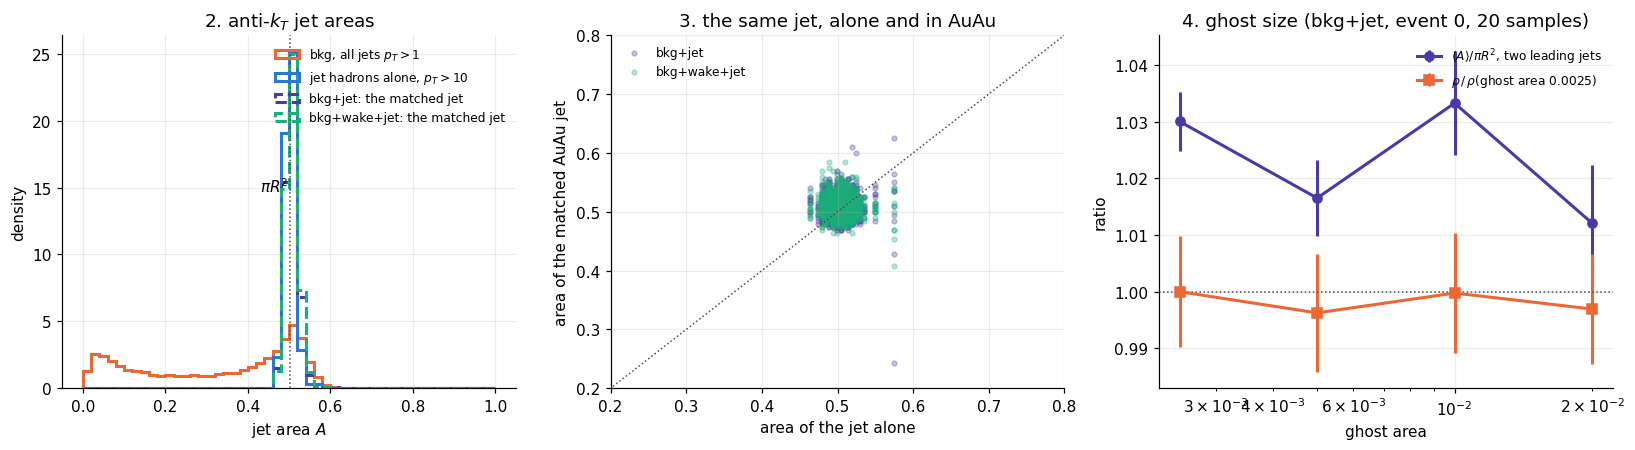


4. ghost area   <A>/piR^2 (2 leading)   rho (GeV)
     0.0200      1.012 +- 0.010        56.97 +- 0.56
     0.0100      1.033 +- 0.009        57.13 +- 0.61
     0.0050      1.017 +- 0.007        56.93 +- 0.60
     0.0025      1.030 +- 0.005        57.14 +- 0.56


In [7]:
print("1. total area / acceptance 2*eta_max*2*pi = %.4f:" % ACC_AREA)
print(f"   jet hadrons alone: {np.min(total_area_frag):.4f} .. {np.max(total_area_frag):.4f}")
for leg in LEGS:
    a = R_REC[leg]["total_area"]
    print(f"   {leg:13s}: {a.min():.4f} .. {a.max():.4f}")
ghost = fj.GhostedAreaSpec(ETA_MAX, 1, GHOST_AREA)
print(f"   ghost area asked {GHOST_AREA}, actual {ghost.actual_ghost_area():.5f}; "
      f"{int(round(ACC_AREA / ghost.actual_ghost_area()))} ghosts per event")

A0 = np.pi * R ** 2
A_BINS = np.linspace(0, 1.0, 51)
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axs[0]
for leg, sel, lab in (("bkg", J_REC["bkg"]["pt"] > 1, r"bkg, all jets $p_T > 1$"),
                      ("bkg+wake+jet", None, None)):
    if sel is None:
        continue
    ax.hist(J_REC[leg]["area"][sel], A_BINS, density=True, histtype="step", lw=2, color=COL[leg], label=lab)
ax.hist(FJ["area"], A_BINS, density=True, histtype="step", lw=2, color=COL["jet"],
        label=rf"jet hadrons alone, $p_T > {JET_PT_MIN_FRAG:.0f}$")
for leg in LEGS[1:]:
    ax.hist(M_REC[leg]["area"], A_BINS, density=True, histtype="step", lw=2, ls="--", color=COL[leg],
            label=f"{leg}: the matched jet")
ax.axvline(A0, color="0.3", lw=1, ls=":"); ax.text(A0, ax.get_ylim()[1] * 0.6, r"$\pi R^2$ ", ha="right", va="top")
ax.set(xlabel="jet area $A$", ylabel="density", title="2. anti-$k_T$ jet areas")
ax.legend(fontsize=8, loc="upper right")

ax = axs[1]
for leg in LEGS[1:]:
    m = M_REC[leg]
    ax.scatter(m["area_frag"], m["area"], s=10, alpha=0.3, color=COL[leg], label=leg)
ax.plot([0, 1], [0, 1], color="0.3", lw=1, ls=":")
ax.set(xlim=(0.2, 0.8), ylim=(0.2, 0.8), xlabel="area of the jet alone", ylabel="area of the matched AuAu jet",
       title="3. the same jet, alone and in AuAu")
ax.legend(fontsize=8)
print("\n2./3. <A>/(pi R^2):  jet hadrons alone %.3f (rms %.3f)" % (FJ["area"].mean() / A0, FJ["area"].std() / A0))
for leg in LEGS[1:]:
    m = M_REC[leg]
    print(f"   {leg:13s} matched jets {m['area'].mean() / A0:.3f} (rms {m['area'].std() / A0:.3f}),  "
          f"same jet alone {m['area_frag'].mean() / A0:.3f}")
b = J_REC["bkg"]
print(f"   bkg jets pT > 1 GeV: <A>/(pi R^2) = {b['area'][b['pt'] > 1].mean() / A0:.3f} "
      f"(soft jets share the area: {len(b['pt']) / N_AUAU:.1f} jets per event in |eta| < {JET_ETA:.1f})")

# 4. ghost-size scan on the first event's embedded samples
ax = axs[2]
e = int(EVENTS[0])
n_scan = min(20, N_OVER[e])
scan = []
for ga in (0.02, 0.01, 0.005, 0.0025):
    ad = area_def(ga)
    rhos, areas = [], []
    for k in range(n_scan):
        j = k % N_FRAG[e]
        parts = to_pseudojets(reader.background_event(e, k)) + to_pseudojets(frag_sample(e, j), FRAG_OFFSET)
        csk = fj.ClusterSequenceArea(parts, BKG_DEF, ad)
        est = fj.JetMedianBackgroundEstimator(SEL_RHO, BKG_DEF, ad)
        est.set_use_area_4vector(False)
        est.set_jets(csk.inclusive_jets())
        rhos.append(est.rho())
        cs = fj.ClusterSequenceArea(parts, JET_DEF, ad)
        jets = fj.sorted_by_pt(SEL_JET(cs.inclusive_jets(1.0)))
        areas += [jt.area() for jt in jets[:2]]
    scan.append((ga, np.mean(areas), np.std(areas) / np.sqrt(len(areas)), np.mean(rhos), np.std(rhos) / np.sqrt(len(rhos))))
scan = np.array(scan)
ax.errorbar(scan[:, 0], scan[:, 1] / A0, scan[:, 2] / A0, marker="o", ms=6, color=COL["bkg+jet"],
            label=r"$\langle A\rangle/\pi R^2$, two leading jets")
ax.errorbar(scan[:, 0], scan[:, 3] / scan[-1, 3], scan[:, 4] / scan[-1, 3], marker="s", ms=6, color=COL["bkg"],
            label=r"$\rho\,/\,\rho$(ghost area 0.0025)")
ax.axhline(1, color="0.3", lw=1, ls=":")
ax.set(xscale="log", xlabel="ghost area", ylabel="ratio", title=f"4. ghost size (bkg+jet, event {e}, {n_scan} samples)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("\n4. ghost area   <A>/piR^2 (2 leading)   rho (GeV)")
for ga, a, ae, r_, re in scan:
    print(f"   {ga:8.4f}      {a / A0:.3f} +- {ae / A0:.3f}        {r_:.2f} +- {re:.2f}")

## 4. $\rho$ from $k_T$ jets without the two leading ones

$\rho$ = median over the $k_T$ jets in $|\eta| < \eta_\mathrm{max} - R$ of $p_{T}/A$, after removing the
two hardest of them (FastJet's median also counts ghost-only jets as empty, which lowers $\rho$ in sparse
events; the table gives their number). Compared with:

* $\rho$ **without the exclusion** — the leading $k_T$ jets are the hard jets; with two of $\sim 40$
  $k_T$ jets affected, the median moves little, which is the point of using a median;
* the **mean** $p_T$ density $\sum p_T / (\Delta\eta\,2\pi)$ over the same acceptance — larger than the median,
  since the $p_T/A$ distribution has a high-side tail (jets, fluctuations);
* the same oversample **without and with the jet**: bkg and bkg+jet share the background hadrons, so their
  difference is the jet's own effect on $\rho$; bkg+wake+jet adds the medium response. The same bkg
  sample clustered twice (new ghosts) shows how much of that spread is the ghosts' jitter alone.

Each event is its own fluid, so $\rho$ has one peak per event (printed below).

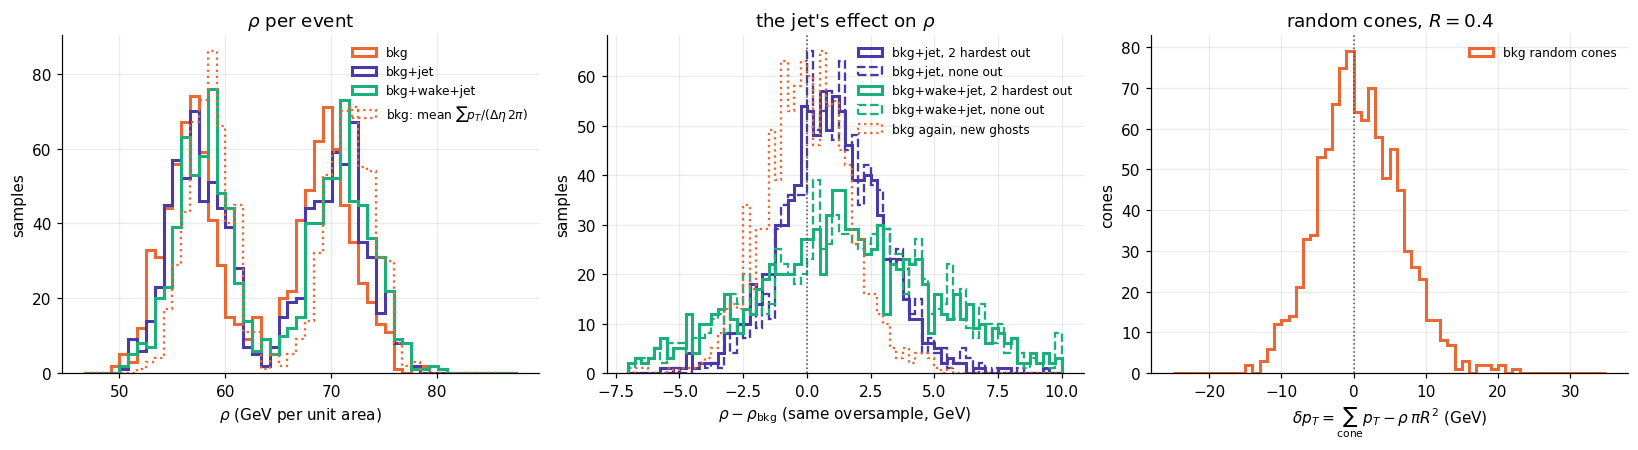

                          rho  rho, none out  mean density   sigma  kT jets  empty  2 hardest kT jets (GeV)
bkg              63.13 +- 7.04    63.65          65.13       6.38    43.1    0.0   [39.9 35.4]
bkg+jet          64.05 +- 7.26    64.77          69.43       6.53    42.8    0.0   [62.5 46.9]
bkg+wake+jet     64.51 +- 7.21    65.28          69.88       6.65    42.8    0.0   [63.  47.4]
rho(bkg+jet) - rho(bkg): +0.916 +- 0.062 GeV (2 hardest out),  +1.126 +- 0.060 (none out); x pi R^2 = +0.46 GeV per jet
rho(bkg+wake+jet) - rho(bkg): +1.383 +- 0.119 GeV (2 hardest out),  +1.637 +- 0.118 (none out); x pi R^2 = +0.70 GeV per jet
rho(bkg, new ghosts) - rho(bkg): +0.012, rms 1.694 GeV (the ghosts' jitter)
per event, bkg rho (GeV): event 0: 56.6, event 1: 69.6
random cones: <delta pT> = +0.87 +- 0.18 GeV, sigma = 5.61 GeV  (sigma * sqrt(pi R^2) = 4.52)


In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axs[0]
lo = min(R_REC[l]["rho"].min() for l in LEGS) - 3
hi = max(R_REC[l]["rho_naive"].max() for l in LEGS) + 3
bins = np.linspace(lo, hi, 50)
for leg in LEGS:
    ax.hist(R_REC[leg]["rho"], bins, histtype="step", lw=2, color=COL[leg], label=f"{leg}")
ax.hist(R_REC["bkg"]["rho_naive"], bins, histtype="step", lw=1.5, ls=":", color=COL["bkg"],
        label=r"bkg: mean $\sum p_T/(\Delta\eta\,2\pi)$")
ax.set(xlabel=r"$\rho$ (GeV per unit area)", ylabel="samples", title=r"$\rho$ per event")
ax.legend(fontsize=8)

ax = axs[1]
b = R_REC["bkg"]["rho"]
bins = np.linspace(-7, 10, 69)
for leg in LEGS[1:]:
    ax.hist(R_REC[leg]["rho"] - b, bins, histtype="step", lw=2, color=COL[leg],
            label=f"{leg}, {N_EXCL} hardest out")
    ax.hist(R_REC[leg]["rho0"] - R_REC["bkg"]["rho0"], bins, histtype="step", lw=1.5, ls="--",
            color=COL[leg], label=f"{leg}, none out")
ax.hist(RHO_REGHOST - b, bins, histtype="step", lw=1.5, ls=":", color=COL["bkg"],
        label="bkg again, new ghosts")
ax.axvline(0, color="0.3", lw=1, ls=":")
ax.set(xlabel=r"$\rho - \rho_\mathrm{bkg}$ (same oversample, GeV)", ylabel="samples",
       title="the jet's effect on $\\rho$")
ax.legend(fontsize=8)

ax = axs[2]
dpt = RC["sum_pt"] - RC["rho"] * np.pi * R ** 2
bins = np.linspace(-25, 35, 61)
ax.hist(dpt, bins, histtype="step", lw=2, color=COL["bkg"], label="bkg random cones")
ax.axvline(0, color="0.3", lw=1, ls=":")
ax.set(xlabel=r"$\delta p_T = \sum_\mathrm{cone} p_T - \rho\,\pi R^2$ (GeV)", ylabel="cones",
       title=rf"random cones, $R = {R}$")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'':14s} {'rho':>14s} {'rho, none out':>14s} {'mean density':>13s} {'sigma':>7s} {'kT jets':>8s} "
      f"{'empty':>6s}  2 hardest kT jets (GeV)")
for leg in LEGS:
    r = R_REC[leg]
    lead = np.array([x + [np.nan] * (N_EXCL - len(x)) for x in r["lead_kt"]])
    print(f"{leg:14s} {r['rho'].mean():7.2f} +- {r['rho'].std():4.2f} {r['rho0'].mean():8.2f}       "
          f"{r['rho_naive'].mean():8.2f}     {r['sigma'].mean():6.2f} {r['n_kt'].mean():7.1f}  "
          f"{r['n_empty'].mean():5.1f}   {np.nanmean(lead, axis=0).round(1)}")
for leg in LEGS[1:]:
    d = R_REC[leg]["rho"] - b
    d0 = R_REC[leg]["rho0"] - R_REC["bkg"]["rho0"]
    print(f"rho({leg}) - rho(bkg): {d.mean():+.3f} +- {d.std() / np.sqrt(len(d)):.3f} GeV "
          f"({N_EXCL} hardest out),  {d0.mean():+.3f} +- {d0.std() / np.sqrt(len(d0)):.3f} (none out); "
          f"x pi R^2 = {d.mean() * np.pi * R ** 2:+.2f} GeV per jet")
g = RHO_REGHOST - b
print(f"rho(bkg, new ghosts) - rho(bkg): {g.mean():+.3f}, rms {g.std():.3f} GeV (the ghosts' jitter)")
print("per event, bkg rho (GeV): " + ", ".join(
    f"event {e}: {R_REC['bkg']['rho'][R_REC['bkg']['event'] == e].mean():.1f}" for e in EVENTS[:10]))
print(f"random cones: <delta pT> = {dpt.mean():+.2f} +- {dpt.std() / np.sqrt(len(dpt)):.2f} GeV, "
      f"sigma = {dpt.std():.2f} GeV  (sigma * sqrt(pi R^2) = {R_REC['bkg']['sigma'].mean() * np.sqrt(np.pi * R ** 2):.2f})")

## 5. Jet spectrum with and without $\rho A$ subtraction

Anti-$k_T$ jets in $|\eta| < \eta_\mathrm{max} - R$, raw $p_T$ and $p_T - \rho A$ with the event's own $\rho$,
against the jets of the jet hadrons alone (section 2, per fragmentation sample). The raw spectrum sits
on the background: every jet carries $\approx \rho\,\pi R^2$ of it, and the $\sim$ 30 jets per event of the
background alone (about 40 per event above 1 GeV) make a combinatorial spectrum that dominates up to
$\sim 20$–30 GeV. Subtraction shifts
the jets back; what is left at low $p_T$ is the combinatorial part, spread by the background
fluctuations $\sigma_{\delta p_T}$ around 0.

**Embedding.** Each jet of the jet hadrons alone is matched to the AuAu jet with the largest $p_T$
from its hadrons (known from `user_index`), and $\delta p_T = (p_T - \rho A) - p_{T,\mathrm{alone}}$:
for bkg+jet it must be centered at 0 with the random-cone width; for bkg+wake+jet it adds the medium
response inside the cone (positive: the wake's excess, minus the diffusion wake's depletion).

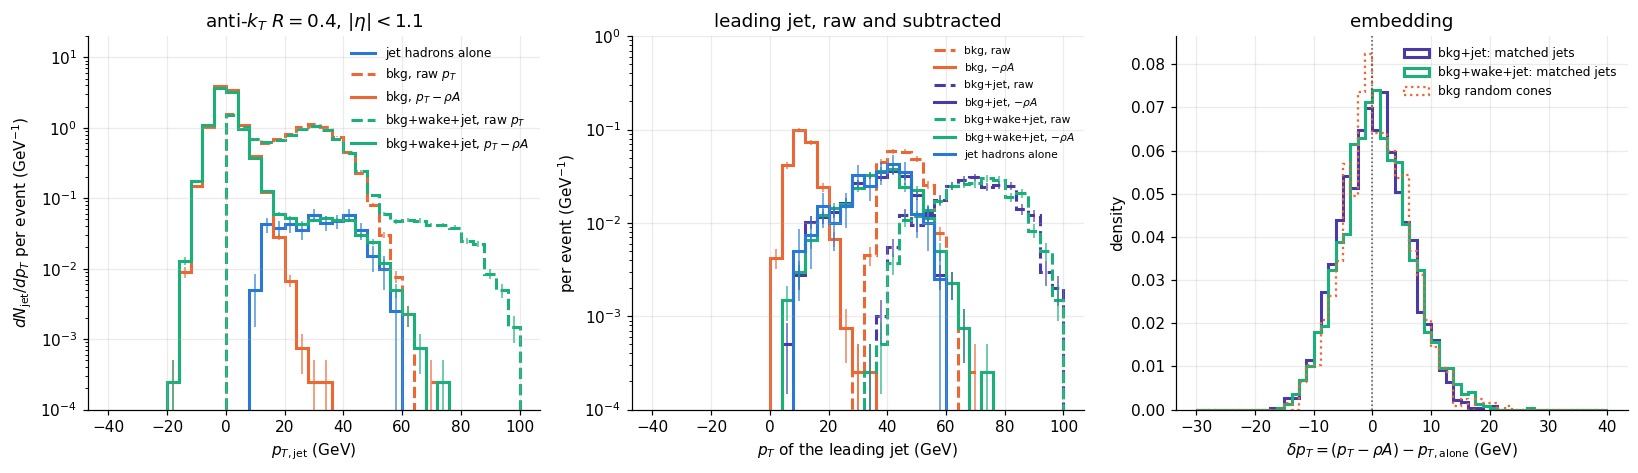

jets per event in |eta| < 1.1 (pT > 1 GeV): bkg 40.6, bkg+jet 40.6, bkg+wake+jet 40.6
bkg+jet      : 1730 of 1730 jets matched (> 50% of their pT in one AuAu jet; median dR 0.040):  raw pT - pT alone +33.11,  (pT - rho A) - pT alone +0.29 +- 0.14 GeV, sigma 5.71
bkg+wake+jet : 1730 of 1730 jets matched (> 50% of their pT in one AuAu jet; median dR 0.041):  raw pT - pT alone +33.87,  (pT - rho A) - pT alone +0.79 +- 0.14 GeV, sigma 5.91
random cones on bkg: <delta pT> +0.87, sigma 5.61 GeV

leading jet, mean pT (GeV):   raw     pT - rho A
   bkg                      45.51    11.60
   bkg+jet                  69.21    36.61
   bkg+wake+jet             69.69    36.83
   jet hadrons alone        35.97


In [9]:
PT_E = np.arange(-40, 104, 4.0)
fig, axs = plt.subplots(1, 3, figsize=(15, 4.4))
ax = axs[0]
h, err = per_sample_hist(FJ["pt"], FJ["event"], PT_E, N_FRAG)
step(ax, PT_E, h, err, "jet hadrons alone", COL["jet"])
for leg in ("bkg", "bkg+wake+jet"):
    J = J_REC[leg]
    h, err = per_sample_hist(J["pt"], J["event"], PT_E, N_OVER)
    step(ax, PT_E, h, err, rf"{leg}, raw $p_T$", COL[leg], ls="--")
    h, err = per_sample_hist(J["pt"] - J["rho"] * J["area"], J["event"], PT_E, N_OVER)
    step(ax, PT_E, h, err, rf"{leg}, $p_T - \rho A$", COL[leg])
ax.set(yscale="log", ylim=(1e-4, 20), xlabel=r"$p_{T,\mathrm{jet}}$ (GeV)",
       ylabel=r"$dN_\mathrm{jet}/dp_T$ per event (GeV$^{-1}$)", title=rf"anti-$k_T$ $R={R}$, $|\eta|<{JET_ETA:.1f}$")
ax.legend(fontsize=8)

ax = axs[1]   # the leading jet per event, raw and subtracted
lead = {}
for leg in LEGS:
    J = J_REC[leg]
    key = J["event"] * 100000 + J["k"]
    first = np.r_[True, np.diff(key) != 0]           # jets are sorted by raw pT inside a sample
    lead[leg] = {"raw": J["pt"][first], "sub": (J["pt"] - J["rho"] * J["area"])[first], "event": J["event"][first]}
    h, err = per_sample_hist(lead[leg]["raw"], lead[leg]["event"], PT_E, N_OVER)
    step(ax, PT_E, h, err, f"{leg}, raw", COL[leg], ls="--")
    h, err = per_sample_hist(lead[leg]["sub"], lead[leg]["event"], PT_E, N_OVER)
    step(ax, PT_E, h, err, rf"{leg}, $-\rho A$", COL[leg])
fl = np.r_[True, (np.diff(FJ["event"]) != 0) | (np.diff(FJ["sample"]) != 0)]
h, err = per_sample_hist(FJ["pt"][fl], FJ["event"][fl], PT_E, N_FRAG)
step(ax, PT_E, h, err, "jet hadrons alone", COL["jet"])
ax.set(yscale="log", ylim=(1e-4, 1), xlabel=r"$p_{T}$ of the leading jet (GeV)", ylabel="per event (GeV$^{-1}$)",
       title="leading jet, raw and subtracted")
ax.legend(fontsize=7)

ax = axs[2]
bins = np.linspace(-30, 40, 57)
for leg in LEGS[1:]:
    m = M_REC[leg]
    ok = m["frag_share"] > 0.5
    ax.hist((m["pt"] - m["rho"] * m["area"] - m["pt_frag"])[ok], bins, density=True, histtype="step", lw=2,
            color=COL[leg], label=f"{leg}: matched jets")
ax.hist(dpt, bins, density=True, histtype="step", lw=1.5, ls=":", color=COL["bkg"], label="bkg random cones")
ax.axvline(0, color="0.3", lw=1, ls=":")
ax.set(xlabel=r"$\delta p_T = (p_T - \rho A) - p_{T,\mathrm{alone}}$ (GeV)", ylabel="density",
       title="embedding")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"jets per event in |eta| < {JET_ETA:.1f} (pT > 1 GeV): " +
      ", ".join(f"{leg} {len(J_REC[leg]['pt']) / N_AUAU:.1f}" for leg in LEGS))
for leg in LEGS[1:]:
    m = M_REC[leg]
    ok = m["frag_share"] > 0.5
    d = (m["pt"] - m["rho"] * m["area"] - m["pt_frag"])[ok]
    draw = (m["pt"] - m["pt_frag"])[ok]
    print(f"{leg:13s}: {ok.sum()} of {len(ok)} jets matched (> 50% of their pT in one AuAu jet; median dR "
          f"{np.median(m['dR'][ok]):.3f}):  raw pT - pT alone {draw.mean():+.2f},  "
          f"(pT - rho A) - pT alone {d.mean():+.2f} +- {d.std() / np.sqrt(len(d)):.2f} GeV, sigma {d.std():.2f}")
print(f"random cones on bkg: <delta pT> {dpt.mean():+.2f}, sigma {dpt.std():.2f} GeV")
print("\nleading jet, mean pT (GeV):   raw     pT - rho A")
for leg in LEGS:
    print(f"   {leg:13s}           {lead[leg]['raw'].mean():6.2f}   {lead[leg]['sub'].mean():6.2f}")
print(f"   jet hadrons alone       {FJ['pt'][fl].mean():6.2f}")

## 6. Summary

The cell below collects the numbers the checks above rest on.

In [10]:
A_ALONE = FJ["area"].mean() / A0
m = M_REC["bkg+jet"]; ok = m["frag_share"] > 0.5
d_emb = (m["pt"] - m["rho"] * m["area"] - m["pt_frag"])[ok]
m2 = M_REC["bkg+wake+jet"]; ok2 = m2["frag_share"] > 0.5
d_wake = (m2["pt"] - m2["rho"] * m2["area"] - m2["pt_frag"])[ok2]
rows = [
    ("events x samples (jet hadrons / AuAu)", f"{N_EV} x {N_FRAG_SAMPLES // max(N_EV, 1)} / {N_EV} x {N_AUAU // max(N_EV, 1)}"),
    ("sum of jet areas / acceptance", f"{min(R_REC[l]['total_area'].min() for l in LEGS) / ACC_AREA:.5f} .. "
                                      f"{max(R_REC[l]['total_area'].max() for l in LEGS) / ACC_AREA:.5f}"),
    ("<A>/piR^2: jet alone / matched in bkg", f"{A_ALONE:.3f} / {m['area'][ok].mean() / A0:.3f}"),
    ("rho bkg (median, 2 out) / mean density", f"{R_REC['bkg']['rho'].mean():.1f} / {R_REC['bkg']['rho_naive'].mean():.1f} GeV"),
    ("rho(bkg+jet) - rho(bkg): 2 out / none out",
     f"{(R_REC['bkg+jet']['rho'] - R_REC['bkg']['rho']).mean():+.2f} / "
     f"{(R_REC['bkg+jet']['rho0'] - R_REC['bkg']['rho0']).mean():+.2f} GeV"),
    ("rho(bkg+wake+jet) - rho(bkg)", f"{(R_REC['bkg+wake+jet']['rho'] - R_REC['bkg']['rho']).mean():+.2f} GeV"),
    ("random cone <dpT>, sigma", f"{dpt.mean():+.2f}, {dpt.std():.2f} GeV"),
    ("embedding <dpT>, sigma (bkg+jet)", f"{d_emb.mean():+.2f} +- {d_emb.std() / np.sqrt(len(d_emb)):.2f}, {d_emb.std():.2f} GeV"),
    ("embedding <dpT>, sigma (bkg+wake+jet)", f"{d_wake.mean():+.2f} +- {d_wake.std() / np.sqrt(len(d_wake)):.2f}, {d_wake.std():.2f} GeV"),
]
w = max(len(a) for a, _ in rows)
for a, b_ in rows:
    print(f"{a:{w}s}  {b_}")

events x samples (jet hadrons / AuAu)      2 x 50 / 2 x 500
sum of jet areas / acceptance              1.00000 .. 1.00000
<A>/piR^2: jet alone / matched in bkg      1.003 / 1.011
rho bkg (median, 2 out) / mean density     63.1 / 65.1 GeV
rho(bkg+jet) - rho(bkg): 2 out / none out  +0.92 / +1.13 GeV
rho(bkg+wake+jet) - rho(bkg)               +1.38 GeV
random cone <dpT>, sigma                   +0.87, 5.61 GeV
embedding <dpT>, sigma (bkg+jet)           +0.29 +- 0.14, 5.71 GeV
embedding <dpT>, sigma (bkg+wake+jet)      +0.79 +- 0.14, 5.91 GeV
